In [ ]:
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib import figure
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
# Step 1: Load the dataset
print("Loading the dataset...")
df = pd.read_csv('IRIS.csv')
print(f"Dataset Loaded. Total samples: {len(df)}")
print("Sample data:\n", df.head(), "\n")

Loading the dataset...
Dataset Loaded. Total samples: 150
Sample data:
    sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa 



In [ ]:
# Step 2: Prepare the feature set and target variable
X = df.drop('species', axis=1)  # Features
y = df['species']  # Target variable
print("Feature columns:", list(X.columns))
print("Target classes:", y.unique(), "\n")

Feature columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Target classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica'] 



In [ ]:
# Step 3: Implement K-Fold Cross-Validation
k = 5
kfold = KFold(n_splits=k, shuffle=True, random_state=42)
print(f"Applying {k}-Fold Cross-Validation...\n")

Applying 5-Fold Cross-Validation...



In [ ]:
# Initialize lists to store accuracy scores
rf_accuracies = []
svm_accuracies = []
lr_accuracies = []

In [ ]:
# Loop through each fold
for fold, (train_index, test_index) in enumerate(kfold.split(X), 1):
    print(f"Fold {fold}:")
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    print(f"  Training on {len(train_index)} samples, Testing on {len(test_index)} samples")

    # Random Forest
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    rf_predictions = rf_model.predict(X_test)
    rf_accuracy = accuracy_score(y_test, rf_predictions)
    rf_accuracies.append(rf_accuracy)
    print(f"  Random Forest Accuracy: {rf_accuracy:.2f}")
    
    # Support Vector Machine
    svm_model = SVC(random_state=42)
    svm_model.fit(X_train, y_train)
    svm_predictions = svm_model.predict(X_test)
    svm_accuracy = accuracy_score(y_test, svm_predictions)
    svm_accuracies.append(svm_accuracy)
    print(f"  SVM Accuracy: {svm_accuracy:.2f}")
    
    # Logistic Regression
    lr_model = LogisticRegression(max_iter=200, random_state=42)
    lr_model.fit(X_train, y_train)
    lr_predictions = lr_model.predict(X_test)
    lr_accuracy = accuracy_score(y_test, lr_predictions)
    lr_accuracies.append(lr_accuracy)
    print(f"  Logistic Regression Accuracy: {lr_accuracy:.2f}\n")

Fold 1:
  Training on 120 samples, Testing on 30 samples
  Random Forest Accuracy: 1.00
  SVM Accuracy: 1.00
  Logistic Regression Accuracy: 1.00

Fold 2:
  Training on 120 samples, Testing on 30 samples
  Random Forest Accuracy: 0.97
  SVM Accuracy: 1.00
  Logistic Regression Accuracy: 1.00

Fold 3:
  Training on 120 samples, Testing on 30 samples
  Random Forest Accuracy: 0.93
  SVM Accuracy: 0.93
  Logistic Regression Accuracy: 0.93

Fold 4:
  Training on 120 samples, Testing on 30 samples
  Random Forest Accuracy: 0.93
  SVM Accuracy: 0.93
  Logistic Regression Accuracy: 0.97

Fold 5:
  Training on 120 samples, Testing on 30 samples
  Random Forest Accuracy: 0.97
  SVM Accuracy: 0.97
  Logistic Regression Accuracy: 0.97



In [ ]:
# Step 4: Calculate and print the average accuracy for each model
print("Final Average Accuracies after Cross-Validation:")
print(f"  ➤ Random Forest Average Accuracy: {sum(rf_accuracies) / len(rf_accuracies):.2f}")
print(f"  ➤ SVM Average Accuracy: {sum(svm_accuracies) / len(svm_accuracies):.2f}")
print(f"  ➤ Logistic Regression Average Accuracy: {sum(lr_accuracies) / len(lr_accuracies):.2f}")


Final Average Accuracies after Cross-Validation:
  ➤ Random Forest Average Accuracy: 0.96
  ➤ SVM Average Accuracy: 0.97
  ➤ Logistic Regression Average Accuracy: 0.97


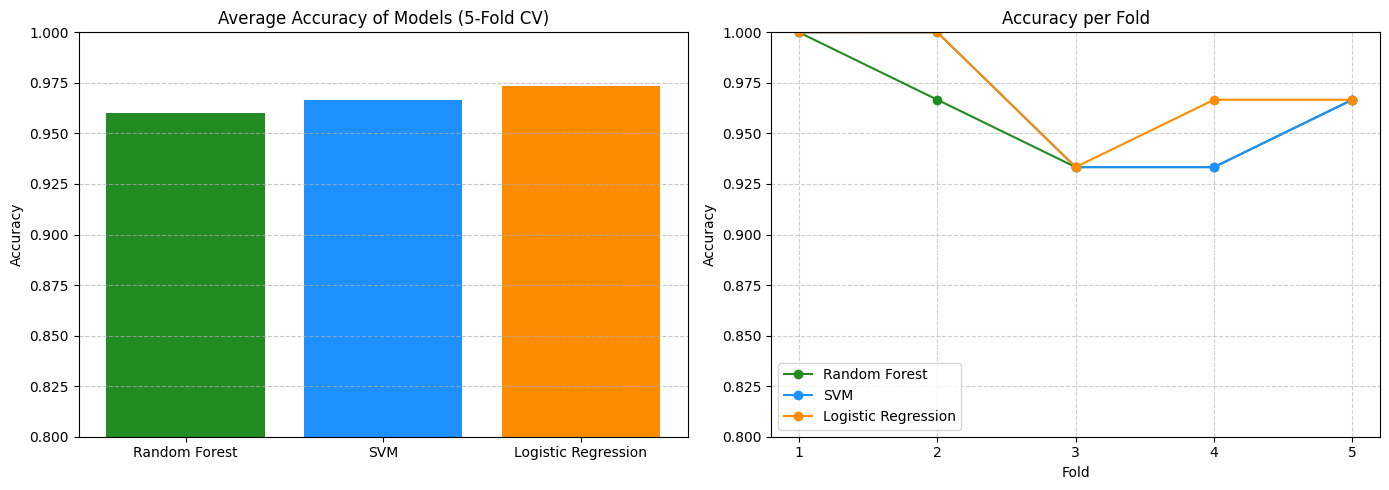

In [ ]:
# Calculate average accuracies
avg_rf = sum(rf_accuracies) / k
avg_svm = sum(svm_accuracies) / k
avg_lr = sum(lr_accuracies) / k

# === PLOTS === #

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Bar Chart of Average Accuracy
models = ['Random Forest', 'SVM', 'Logistic Regression']
avg_scores = [avg_rf, avg_svm, avg_lr]

axes[0].bar(models, avg_scores, color=['forestgreen', 'dodgerblue', 'darkorange'])
axes[0].set_title('Average Accuracy of Models (5-Fold CV)')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.8, 1.0)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Line Plot of Accuracy per Fold
folds = list(range(1, k + 1))

axes[1].plot(folds, rf_accuracies, marker='o', label='Random Forest', color='forestgreen')
axes[1].plot(folds, svm_accuracies, marker='o', label='SVM', color='dodgerblue')
axes[1].plot(folds, lr_accuracies, marker='o', label='Logistic Regression', color='darkorange')
axes[1].set_title('Accuracy per Fold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.8, 1.0)
axes[1].set_xticks(folds)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()
